# Which segment carried the fall from Q1 to Q2, and how often did its customers order?

**Week 2, Monday. Chapter 3 of 6.** Chapters 1 and 2 answered the tree for the whole book;
this chapter answers it for each segment.

**The case.** The cohort are trainee engineers in the data and AI team at Kalpa's Global
Capability Centre, and Kalpa Retail is their internal client. Anand Iyer, its finance
controller, signs a Monday sheet of the revenue tree for every segment, and his analyst reruns
every query behind it before reading a number. Meera Raghavan, Kalpa Retail's CEO, sets budgets
from the sheet. Kavya Nair, the team's senior analyst, reviews each chapter's answer before it
leaves the team. The book is Kalpa Retail's record of every order Finance stands behind; it
lives in the warehouse, Kalpa's Postgres database, which holds the orders for Q1 (April to June
2026) and Q2 (July to September 2026). Booked revenue counts every order at its amount, whatever
its status.

> "I want these numbers every Monday, for every segment and channel."
> Anand Iyer, finance controller, Kalpa Retail

**Who needs the answer.** Anand's sheet carries one line per segment, and the head of
Retail-Plus reads the Retail-Plus line to decide which members the team works to keep. A wrong
frequency on that line sends the retention budget to the wrong segment: a tier whose members
seem to order half as often gets an emergency plan, and a segment that seems to order twice as
often gets money it does not need.

**The questions on the way.**
1. One query per segment, one grouped query, or pandas?
2. How many orders, customers and rupees did each segment book in each quarter?
3. Which segment-quarters hold too few customers to quote a rate on?
4. How often did each segment's customers order?
5. Does the average of each customer's own order count agree?

**The metric at stake.** Revenue per segment and quarter, and orders per customer per segment:
orders in the quarter divided by the customers who bought in it. Kalpa sells to four segments:
Business (corporate buyers), Retail-Core (everyday shoppers), Retail-Plus (the paid membership
tier) and Student. Revenue is booked revenue. Q1 is April to June 2026 and Q2 is July to
September 2026.

**What chapters 1 and 2 found.** The book fell 1.6 percent, from Rs 10,00,00,000 on 538 orders
to Rs 9,84,00,000 on 462. The customers who bought fell from 244 to 227, and each ordered 7.7
percent less often. Last week's note said Retail-Plus members were ordering less often; the
book has not yet been asked about any single segment.

**A real company with the same question.** Eternal, the company behind Zomato and Blinkit,
reported that its consumer businesses' net order value grew 54 percent year on year to
Rs 31,120 crore in the quarter to 30 June 2026, and in the same letter that food delivery grew
a little over 20 percent (Rs 10,769 crore), quick commerce 86 percent (Rs 17,132 crore) and
going-out 60 percent (Rs 3,218 crore) (Eternal, shareholders' letter for Q1 FY27, 22 July 2026).
Kalpa's 1.6 percent fall is the sum of four segments' changes, and this chapter puts each on its
own row.

**Setup.** The next cell finds the shared helper, `c2kit`, by walking up from this folder
until it reaches `scripts/`, connects to the Kalpa warehouse and reads the named queries in
`../sql/C2_W02_D01_03_which_segment_STUDENT.sql`. Every query below is a block of that file, so what
runs here is exactly what runs from VS Code. If no database answers, the error names the
command that loads the warehouse: `bash .devcontainer/load_warehouse.sh`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import re
from decimal import Decimal
SQL_DIR = kit.data_dir().parent / "sql"

def blocks(stem):
    """Every named block of a .sql file in ../sql/, keyed by the name on its '-- name:' line."""
    text = (SQL_DIR / f"C2_W02_D01_{stem}_STUDENT.sql").read_text(encoding="utf-8")
    parts = re.split(r"^-- name: (\w+)\s*$", text, flags=re.M)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

def statements(block):
    """A block's statements with its comment lines removed, for a block that runs several."""
    bare = "\n".join(l for l in block.splitlines() if not l.strip().startswith("--"))
    return [s.strip() for s in bare.split(";") if s.strip()]

def num(v):
    """A database number as a Python int or float."""
    if isinstance(v, Decimal):
        return int(v) if v == v.to_integral_value() else float(v)
    return v

def show(rows, caption="", money=(), limit=12):
    """Rows from kit.sql as the kit's table, with the columns named in money set in rupees."""
    if not rows:
        kit.table(["result"], [["no rows"]], caption)
        return
    heads = list(rows[0])
    def cell(h, v):
        v = num(v)
        if v is None:
            return "NULL"
        if h in money:
            return kit.rupees(v)
        return f"{v:,}" if isinstance(v, int) and abs(v) >= 10000 else str(v)
    body = [[cell(h, r[h]) for h in heads] for r in rows[:limit]]
    if len(rows) > limit:
        body.append(["..." for _ in heads])
    kit.table(heads, body, caption)

def run(name, caption="", money=(), limit=12):
    """Print a named block, run it, show its rows and hand them back."""
    print(Q[name])
    rows = kit.sql(Q[name])
    show(rows, caption, money, limit)
    return rows

def pct(before, after):
    """The change from before to after, in percent."""
    return 100 * (float(after) - float(before)) / float(before)

Q = blocks("03_which_segment")
print(len(Q), "named queries read from", "C2_W02_D01_03_which_segment_STUDENT.sql;",
      kit.sql("select version()")[0]["version"].split(",")[0])

8 named queries read from C2_W02_D01_03_which_segment_STUDENT.sql; PostgreSQL 16.14 (Ubuntu 16.14-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu


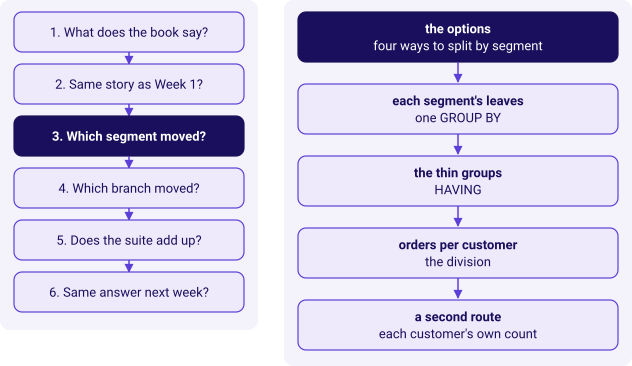

In [2]:
kit.side_by_side(
    kit.ladder(['What does the book say?', 'Same story as Week 1?', 'Which segment moved?', 'Which branch moved?', 'Does the suite add up?', 'Same answer next week?'], lit=2, show=False),
    kit.vflow(['the options\nfour ways to split by segment', "each segment's leaves\none GROUP BY", 'the thin groups\nHAVING', 'orders per customer\nthe division', "a second route\neach customer's own count"], lit=0, show=False),
)

## 1. The options: one query per segment, one grouped query, or pandas?

Four ways a team could put every segment's leaves on Anand's sheet. They differ in how many
queries someone has to keep correct, in the rows each moves, and in what happens the day Kalpa
adds a fifth segment.

| Option | Queries to keep | Rows it moves | When a fifth segment appears |
|---|---|---|---|
| A. One query per segment, `WHERE c.segment = '...'` | Four, one per segment | One row per quarter from each | It is silently missing: no query asks for it |
| B. One query, `GROUP BY c.segment, o.quarter` | One | One row per segment and quarter | It appears as two new rows |
| C. Pull the order rows into pandas and group there | One query and a Python step | Every order row | It appears, on a copy of the book |
| D. One wide row per segment, a column per quarter and measure | One | One row per segment | It appears, and every new measure adds two columns |

The segment lives on the customer, so each option looks up every order's segment with one line,
`JOIN customers c USING (customer_id)`. Joins are Tuesday's topic; today the line is only that
lookup.

**Predict before you run.** Option A's Retail-Plus query is below. How many rows does it
return, and how many would option C move to answer the same question for every segment?

- a) 2 rows, and 1,000.
- b) 8 rows, and 8.
- c) 2 rows, and 8.
- d) 1 row, and 1,000.

In [3]:
one = run("c3_one_segment", "Option A for Retail-Plus: one query, one segment", money=("revenue",))
segments = [r["segment"] for r in kit.sql("SELECT DISTINCT segment FROM customers ORDER BY segment")]
order_rows = kit.sql("SELECT count(*) AS n FROM orders")[0]["n"]
sizing = [("A. a query per segment", f"{len(segments)} queries", f"{len(one) * len(segments)} rows"),
          ("B. one GROUP BY", "1 query", f"{2 * len(segments)} rows"),
          ("C. pandas on the rows", "1 query and Python", f"{order_rows:,} rows"),
          ("D. one wide row per segment", "1 query", f"{len(segments)} rows")]
kit.table(["option", "queries to keep", "rows moved"], sizing,
          caption=f"Sized on this warehouse, which holds {len(segments)} segments")

-- Option A, one query per segment: the Retail-Plus leaves for each quarter.
SELECT o.quarter,
       count(*)                      AS orders,
       count(DISTINCT o.customer_id) AS customers,
       sum(o.amount)                 AS revenue
FROM   orders o
JOIN   customers c USING (customer_id)
WHERE  c.segment = 'Retail-Plus'
GROUP  BY o.quarter
ORDER  BY o.quarter;


quarter,orders,customers,revenue
Q1,215,91,"Rs 5,85,770"
Q2,140,76,"Rs 4,13,380"


option,queries to keep,rows moved
A. a query per segment,4 queries,8 rows
B. one GROUP BY,1 query,8 rows
C. pandas on the rows,1 query and Python,"1,000 rows"
D. one wide row per segment,1 query,4 rows


**What happened.** The answer is a. Option A returns two rows for Retail-Plus, one per quarter,
and needs four queries for the four segments; option C moves all 1,000 order rows to group them
in Python.

**The best-fit call.** Option B, one `GROUP BY c.segment, o.quarter`. One query to keep
correct, eight rows back, and a new segment appears on the sheet the Monday it is created
instead of going missing. **What would change the call:** a one-off question about a single
segment, such as the head of Retail-Plus asking about the tier alone, is option A's job, and
one `WHERE` is the clearest way to write it.

In [4]:
kit.check("the warehouse holds four segments", len(segments) == 4, ", ".join(segments))
kit.check("option A returns one row per quarter", len(one) == 2)

## 2. How many orders, customers and rupees did each segment book in each quarter?

The first try selects the segment and groups only by the quarter. Postgres refuses it, and the
refusal is worth two minutes of reading.

In [5]:
print(Q["c3_group_error"])
with kit.expect_error() as err:
    kit.sql(Q["c3_group_error"])

-- The segment is selected but the grouping names only the quarter. This block stops with an error
-- on purpose: read its last line, then compare it with c3_segments below.
SELECT c.segment, o.quarter, count(*) AS orders
FROM   orders o
JOIN   customers c USING (customer_id)
GROUP  BY o.quarter;


The last line says `column "c.segment" must appear in the GROUP BY clause or be used in an
aggregate function`. In the order a query runs, `GROUP BY` forms the groups before `SELECT`
picks the columns, so each group, here one quarter, holds orders from four segments, and
`SELECT c.segment` has four values to print on one row. There are two fixes: group by the
segment too, or put the segment inside an aggregate such as `min(c.segment)`. The first is the
one the question asks for.

The order a query runs in is the day's one picture. It is written SELECT, FROM, WHERE, GROUP
BY, HAVING, ORDER BY, LIMIT, and it runs as the arrows below show, so SELECT sees groups that
already exist.

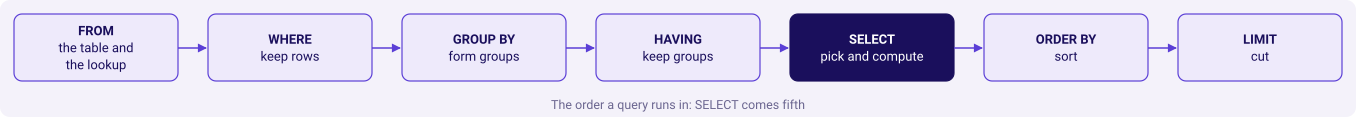

In [6]:
kit.flow(["FROM\nthe table and\nthe lookup", "WHERE\nkeep rows", "GROUP BY\nform groups",
          "HAVING\nkeep groups", "SELECT\npick and compute", "ORDER BY\nsort", "LIMIT\ncut"],
         lit=4, title="The order a query runs in: SELECT comes fifth")

**Predict before you run.** With `GROUP BY c.segment, o.quarter`, how many rows come back?

- a) 2, one per quarter.
- b) 4, one per segment.
- c) 8, one per segment and quarter.
- d) 1,000, one per order.

-- The question: how many orders, customers and rupees did each segment book in each quarter?
-- One row per segment and quarter: 4 segments times 2 quarters.
SELECT c.segment,
       o.quarter,
       count(*)                      AS orders,
       count(DISTINCT o.customer_id) AS customers,
       sum(o.amount)                 AS revenue
FROM   orders o
JOIN   customers c USING (customer_id)
GROUP  BY c.segment, o.quarter
ORDER  BY c.segment, o.quarter;


segment,quarter,orders,customers,revenue
Business,Q1,97,36,"Rs 9,90,14,440"
Business,Q2,91,35,"Rs 9,75,84,600"
Retail-Core,Q1,199,102,"Rs 3,73,070"
Retail-Core,Q2,193,96,"Rs 3,66,250"
Retail-Plus,Q1,215,91,"Rs 5,85,770"
Retail-Plus,Q2,140,76,"Rs 4,13,380"
Student,Q1,27,15,"Rs 26,720"
Student,Q2,38,20,"Rs 35,770"


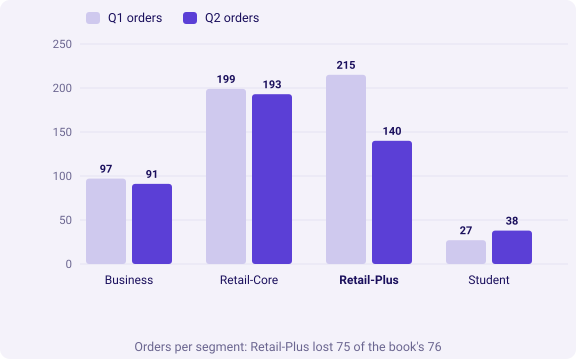

In [7]:
seg = run("c3_segments", "Each segment's leaves in each quarter", money=("revenue",))
by = {(r["segment"], r["quarter"]): {k: num(v) for k, v in r.items()} for r in seg}
kit.columns(segments,
            [("Q1 orders", [by[(s, "Q1")]["orders"] for s in segments]),
             ("Q2 orders", [by[(s, "Q2")]["orders"] for s in segments])],
            title="Orders per segment: Retail-Plus lost 75 of the book's 76", lit=(2,))

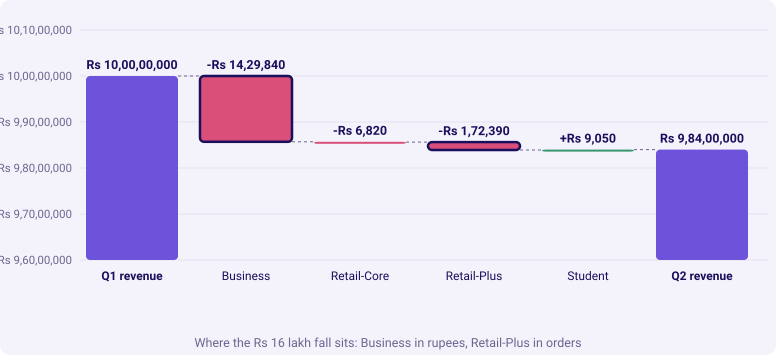

Business        -Rs 14,29,840  -1.4%
Retail-Core         -Rs 6,820  -1.8%
Retail-Plus      -Rs 1,72,390  -29.4%
Student              Rs 9,050  +33.9%


In [8]:
fall = [(s, by[(s, "Q2")]["revenue"] - by[(s, "Q1")]["revenue"]) for s in segments]
kit.bridge(("Q1 revenue", sum(by[(s, "Q1")]["revenue"] for s in segments)), fall,
           end_label="Q2 revenue", lo=96000000, lit=(0, 2),
           title="Where the Rs 16 lakh fall sits: Business in rupees, Retail-Plus in orders")
for s, f in fall:
    print(f"{s:12} {kit.rupees(f):>16}  {pct(by[(s, 'Q1')]['revenue'], by[(s, 'Q2')]['revenue']):+.1f}%")

**What happened.** The answer is c: eight rows. The chart's floor starts at Rs 9.6 crore so the
segment moves are visible against the totals. Business books 99 percent of the rupees, so it
carries Rs 14,29,840 of the Rs 16,00,000 fall on only 6 fewer orders, a 1.4 percent dip.
Retail-Plus lost 75 of the book's 76 fewer orders and 29.4 percent of its revenue, Rs 1,72,390.
Retail-Core fell 1.8 percent and Student rose 33.9 percent. The segment the total hides is
Retail-Plus.

In [9]:
kit.check("eight rows, one per segment and quarter", len(seg) == 8)
kit.check("the segments add back to the book's 538 and 462 orders",
          (sum(by[(s, "Q1")]["orders"] for s in segments), sum(by[(s, "Q2")]["orders"] for s in segments)) == (538, 462))
kit.check("Retail-Plus lost 75 of the 76 fewer orders",
          by[("Retail-Plus", "Q1")]["orders"] - by[("Retail-Plus", "Q2")]["orders"] == 75)
kit.check("Retail-Plus revenue fell 29.4 percent",
          round(pct(by[("Retail-Plus", "Q1")]["revenue"], by[("Retail-Plus", "Q2")]["revenue"]), 1) == -29.4)

## 3. Which segment-quarters hold too few customers to quote a rate on?

Kavya's rule from Week 1 holds here: a rate built on fewer than 30 customers moves a long way
when one customer changes, so it goes on the sheet flagged. The test is on a group, the
customers in a segment and quarter, so it sits in `HAVING`, which runs after the groups exist;
`WHERE` runs before them and tests one order at a time.

**Predict before you run.** Which segment-quarters have fewer than 30 customers?

- a) None.
- b) Student in both quarters.
- c) Student in Q1 only.
- d) Student and Business in both quarters.

-- The question: which segment-quarters hold fewer than 30 customers, too few to quote a rate on?
-- WHERE would test each order row; HAVING tests each group once it exists.
SELECT c.segment,
       o.quarter,
       count(DISTINCT o.customer_id) AS customers
FROM   orders o
JOIN   customers c USING (customer_id)
GROUP  BY c.segment, o.quarter
HAVING count(DISTINCT o.customer_id) < 30
ORDER  BY c.segment, o.quarter;


segment,quarter,customers
Student,Q1,15
Student,Q2,20


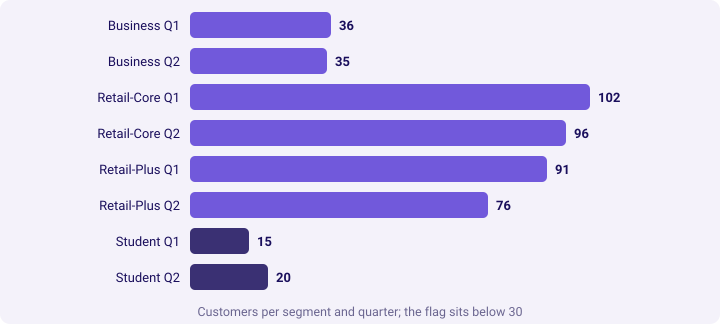

In [10]:
thin = run("c3_thin", "Segment-quarters to flag on the sheet")
kit.bars([(f"{s} {q}", by[(s, q)]["customers"]) for s in segments for q in ("Q1", "Q2")],
         title="Customers per segment and quarter; the flag sits below 30",
         lit=tuple(i for i, (s, q) in enumerate((s, q) for s in segments for q in ("Q1", "Q2"))
                   if by[(s, q)]["customers"] < 30))

**What happened.** The answer is b. Student had 15 customers in Q1 and 20 in Q2, so its 33.9
percent rise goes on the sheet with the flag beside it. Business, with 36 and 35, clears the
bar.

In [11]:
kit.check("two segment-quarters are flagged", len(thin) == 2)
kit.check("both flags are Student", {r["segment"] for r in thin} == {"Student"})

## 4. How often did each segment's customers order?

Orders per customer is orders divided by customers, so the quickest query divides the two
counts it already has:

```sql
count(*) / count(DISTINCT o.customer_id) AS orders_per_customer
```

**Predict before you run.** Retail-Plus placed 215 orders from 91 customers in Q1 and 140 from
76 in Q2. What does the query print for its two quarters?

- a) 2.36 and 1.84.
- b) 2 and 1.
- c) 2.4 and 1.8.
- d) An error, since a count cannot be divided.

In [12]:
hurried = {(r["segment"], r["quarter"]): int(r["orders_per_customer"])
           for r in run("c3_frequency_hurried", "The hurried frequency, exactly as the query returns it")}
kit.table(["segment", "Q1", "Q2", "what the sheet would say"],
          [(s, hurried[(s, "Q1")], hurried[(s, "Q2")],
            "halved" if hurried[(s, "Q2")] * 2 == hurried[(s, "Q1")]
            else "doubled" if hurried[(s, "Q2")] == 2 * hurried[(s, "Q1")] else "no change")
           for s in segments], caption="The plausible wrong answer, segment by segment")

-- The question: how often did each segment's customers order? (The quickest way to write it.)
SELECT c.segment,
       o.quarter,
       count(*) / count(DISTINCT o.customer_id) AS orders_per_customer
FROM   orders o
JOIN   customers c USING (customer_id)
GROUP  BY c.segment, o.quarter
ORDER  BY c.segment, o.quarter;


segment,quarter,orders_per_customer
Business,Q1,2
Business,Q2,2
Retail-Core,Q1,1
Retail-Core,Q2,2
Retail-Plus,Q1,2
Retail-Plus,Q2,1
Student,Q1,1
Student,Q2,1


segment,Q1,Q2,what the sheet would say
Business,2,2,no change
Retail-Core,1,2,doubled
Retail-Plus,2,1,halved
Student,1,1,no change


**The plausible wrong answer.** Retail-Plus 2 then 1: its members' frequency halved. Retail-Core
1 then 2: its customers' frequency doubled. On Anand's sheet the head of Retail-Plus sees an
emergency, and the retention budget moves to Retail-Core, whose customers seem to be ordering
twice as often.

**Why it is wrong.** `count(*)` and `count(DISTINCT ...)` return whole numbers, and Postgres
divides two whole numbers as whole numbers: "for integral types, division truncates the result
towards zero" (PostgreSQL 16 documentation, mathematical functions and operators), so 5 / 2 is
2. The query dropped the fraction without a word. `sum(amount) / count(*)` in chapter 1 kept its
decimals because `amount` is stored as `numeric`. The answer is b.

In [13]:
run("c3_integer_division", "The same two divisions, whole and numeric")

-- What 140 / 76 and 215 / 91 return when both sides are whole numbers, beside the numeric result.
SELECT 215 / 91          AS q1_integer,
       140 / 76          AS q2_integer,
       215::numeric / 91 AS q1_numeric,
       140::numeric / 76 AS q2_numeric;


q1_integer,q2_integer,q1_numeric,q2_numeric
2,1,2.3626373626373627,1.8421052631578947


[{'q1_integer': 2,
  'q2_integer': 1,
  'q1_numeric': Decimal('2.3626373626373626'),
  'q2_numeric': Decimal('1.8421052631578947')}]

**The check that exposes it.** A ratio multiplied by what it divides by gives back what it
divided. Orders per customer times customers must give the orders.

In [14]:
back = [(s, q, hurried[(s, q)], by[(s, q)]["customers"], hurried[(s, q)] * by[(s, q)]["customers"],
         by[(s, q)]["orders"]) for s in segments for q in ("Q1", "Q2")]
kit.table(["segment", "quarter", "ratio", "customers", "ratio x customers", "orders"], back,
          caption="Multiplied back, the hurried ratios lose orders in every row")
kit.check("the hurried ratio multiplied back misses the orders in every row",
          all(r[4] != r[5] for r in back), f"Retail-Plus Q2: 1 x 76 = 76 against 140")

segment,quarter,ratio,customers,ratio x customers,orders
Business,Q1,2,36,72,97
Business,Q2,2,35,70,91
Retail-Core,Q1,1,102,102,199
Retail-Core,Q2,2,96,192,193
Retail-Plus,Q1,2,91,182,215
Retail-Plus,Q2,1,76,76,140
Student,Q1,1,15,15,27
Student,Q2,1,20,20,38


**The fix, and what it changed.** Divide in `numeric`, round on purpose to two places, and keep
the counts beside the ratio so anyone can multiply it back.

-- The fix: divide in numeric, round on purpose to two places, and keep the counts beside the ratio
-- so anyone can multiply it back.
SELECT c.segment,
       o.quarter,
       count(*)                                                    AS orders,
       count(DISTINCT o.customer_id)                               AS customers,
       round(count(*)::numeric / count(DISTINCT o.customer_id), 2) AS orders_per_customer,
       round(sum(o.amount) / count(*))                             AS revenue_per_order
FROM   orders o
JOIN   customers c USING (customer_id)
GROUP  BY c.segment, o.quarter
ORDER  BY c.segment, o.quarter;


segment,quarter,orders,customers,orders_per_customer,revenue_per_order
Business,Q1,97,36,2.69,"Rs 10,20,767"
Business,Q2,91,35,2.6,"Rs 10,72,358"
Retail-Core,Q1,199,102,1.95,"Rs 1,875"
Retail-Core,Q2,193,96,2.01,"Rs 1,898"
Retail-Plus,Q1,215,91,2.36,"Rs 2,725"
Retail-Plus,Q2,140,76,1.84,"Rs 2,953"
Student,Q1,27,15,1.8,Rs 990
Student,Q2,38,20,1.9,Rs 941


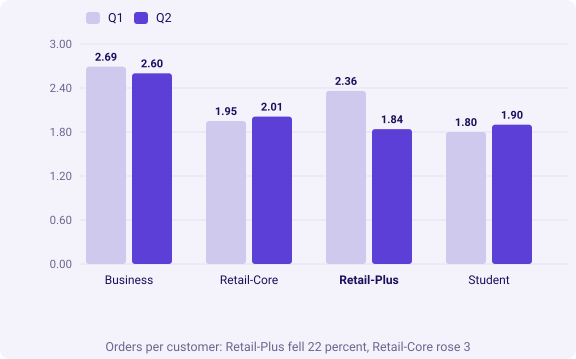

Business     2.69 to 2.60, -3.5% from the unrounded counts
Retail-Core  1.95 to 2.01, +3.0% from the unrounded counts
Retail-Plus  2.36 to 1.84, -22.0% from the unrounded counts
Student      1.80 to 1.90, +5.6% from the unrounded counts


In [15]:
freq = {(r["segment"], r["quarter"]): {k: num(v) for k, v in r.items()}
        for r in run("c3_frequency", "The fix: numeric division, rounded on purpose",
                     money=("revenue_per_order",))}
kit.columns(segments,
            [("Q1", [freq[(s, "Q1")]["orders_per_customer"] for s in segments]),
             ("Q2", [freq[(s, "Q2")]["orders_per_customer"] for s in segments])],
            title="Orders per customer: Retail-Plus fell 22 percent, Retail-Core rose 3",
            fmt=lambda v: f"{v:.2f}", lit=(2,))
for s in segments:
    a, b = freq[(s, "Q1")], freq[(s, "Q2")]
    change = pct(a["orders"] / a["customers"], b["orders"] / b["customers"])
    print(f"{s:12} {a['orders_per_customer']:.2f} to {b['orders_per_customer']:.2f}, "
          f"{change:+.1f}% from the unrounded counts")

In [16]:
plus = (freq[("Retail-Plus", "Q1")]["orders_per_customer"], freq[("Retail-Plus", "Q2")]["orders_per_customer"])
kit.check("Retail-Plus ordered 2.36 then 1.84 times", plus == (2.36, 1.84), f"{plus}")
kit.check("Retail-Core rose, from 1.95 to 2.01",
          (freq[("Retail-Core", "Q1")]["orders_per_customer"], freq[("Retail-Core", "Q2")]["orders_per_customer"]) == (1.95, 2.01))
kit.check("every fixed ratio multiplies back to its orders within half an order",
          all(abs(freq[k]["orders_per_customer"] * freq[k]["customers"] - freq[k]["orders"]) < 0.5 for k in freq))

**What happened.** Retail-Plus members ordered 2.36 times in Q1 and 1.84 times in Q2, a fall of
22.0 percent where the hurried query said 50. Retail-Core rose from 1.95 to 2.01, 3.0 percent
where it said 100. Business went from 2.69 to 2.60, down 3.5 percent, and Student from 1.80 to
1.90, up 5.6 percent; each change is computed from the counts before rounding. The frequency
branch that fell is Retail-Plus's, as last week's note said, and on the book it fell 22.0
percent.

## 5. A second route: does the average of each customer's own order count agree?

The first route divided two counts. The second route never divides counts: it asks the
warehouse for each customer's own number of orders in each quarter, one row per customer and
quarter, and averages those numbers in Python. If the division was right, the average of the
individual counts must equal it.

**Predict before you run.** For Retail-Plus in Q2, what is the average of the 76 customers' own
order counts?

- a) 1, since most bought once.
- b) 1.84.
- c) 2, the median customer.
- d) 140, the orders.

471 rows, one per customer and quarter


segment,quarter,division of counts,average of own counts
Business,Q1,2.69,2.69
Business,Q2,2.60,2.60
Retail-Core,Q1,1.95,1.95
Retail-Core,Q2,2.01,2.01
Retail-Plus,Q1,2.36,2.36
Retail-Plus,Q2,1.84,1.84
Student,Q1,1.80,1.80
Student,Q2,1.90,1.90


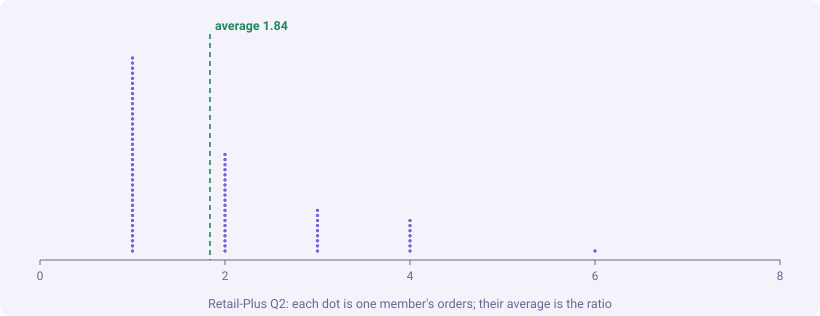

In [17]:
per = kit.sql(Q["c3_per_customer_counts"])
print(f"{len(per)} rows, one per customer and quarter")
groups = {}
for r in per:
    groups.setdefault((r["segment"], r["quarter"]), []).append(int(r["orders"]))
route2 = {k: round(sum(v) / len(v), 2) for k, v in groups.items()}
kit.table(["segment", "quarter", "division of counts", "average of own counts"],
          [(s, q, f"{freq[(s, q)]['orders_per_customer']:.2f}", f"{route2[(s, q)]:.2f}")
           for s in segments for q in ("Q1", "Q2")],
          caption="Two routes to orders per customer")
kit.strip([float(v) for v in groups[("Retail-Plus", "Q2")]],
          markers=[("average", route2[("Retail-Plus", "Q2")], "good")],
          fmt=lambda v: f"{v:g}", lo=0, hi=8,
          title="Retail-Plus Q2: each dot is one member's orders; their average is the ratio")

In [18]:
kit.check("the second route agrees with the numeric division in all eight rows",
          all(route2[k] == freq[k]["orders_per_customer"] for k in freq))
kit.check("the per-customer rows number the customers of the eight groups, 471",
          len(per) == sum(freq[k]["customers"] for k in freq) == 471, f"{len(per)} rows")

**What happened.** The answer is b. The average of the 76 members' own order counts is 1.84, and
all eight segment-quarters agree with the numeric division to two places. The division was
right once it was done in `numeric`.

> **Kavya's review.** Divide in numeric and round on purpose, and keep the counts beside every
> ratio, so anyone reading the sheet can multiply it back.

### In the interview: what do you check when a ratio looks wrong, and what do WHERE and HAVING each do?

**[F] Orders per customer reads 1 for a segment; what do you check first?** Whether the
database divided two whole numbers. In Postgres `count(*) / count(DISTINCT customer_id)` is
integer division and drops the fraction, so 140 orders over 76 customers prints 1. Multiply
the ratio back by the customers: 1 times 76 is 76, not 140. Cast one side to `numeric`, round
to the places the reader needs, and show the counts beside the ratio.

**[S] WHERE against HAVING, one sentence each.** `WHERE` keeps or drops rows before any group
is formed, so it can test a column of one order; `HAVING` keeps or drops groups after they are
formed, so it can test an aggregate such as `count(DISTINCT customer_id) < 30`.

**[S] Explain the logical order in which a SQL query runs.** `FROM` and the lookup first, then
`WHERE`, `GROUP BY`, `HAVING`, `SELECT`, `ORDER BY` and `LIMIT`. It explains the day's refusals:
`SELECT` cannot print a column the groups do not pin down, and `WHERE` cannot test an aggregate
that does not exist yet.

### Depth: why does Postgres divide integers this way, when a spreadsheet does not?

A spreadsheet stores every number as a floating-point value, so 140 / 76 gives 1.84 whatever
you typed. Postgres keeps the type of each value, and an operation on two integers returns an
integer, which is why `215 / 91` is 2 and `215::numeric / 91` is 2.3626. Other databases differ:
some return a decimal from the same division.

## So which segment carried the fall, and how often did its customers order?

1. **One query per segment, one grouped query, or pandas?** One `GROUP BY c.segment,
   o.quarter`: one query, eight rows, and a new segment appears by itself.
2. **What did each segment book?** Business Rs 9,90,14,440 then Rs 9,75,84,600, down 1.4
   percent; Retail-Plus Rs 5,85,770 then Rs 4,13,380, down 29.4 percent on 75 fewer orders;
   Retail-Core down 1.8 percent; Student up 33.9 percent.
3. **Which groups are too thin?** Student in both quarters, with 15 and 20 customers.
4. **How often did each segment's customers order?** Retail-Plus 2.36 then 1.84, down 22.0
   percent; the integer division said 2 then 1, "halved", and put Retail-Core at 1 then 2.
5. **Does the second route agree?** Yes: the average of each customer's own count matches the
   numeric division in all eight rows.

Chapter 4 sets Q1 beside Q2 for every branch in one query, and asks how much less each
Retail-Plus member spent.

In [19]:
kit.check_summary()